url = https://www.youtube.com/watch?v=khMzi6xPbuM

# REPEAT OF BASIC NN

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import lightning as L
from torch.utils.data import TensorDataset, DataLoader 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [8]:
class BasicNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)

        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16.), requires_grad=False)

    def forward(self, input):

        input_to_top_relu = (input*self.w00) + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = (input*self.w10) + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = (scaled_top_relu_output + 
                               scaled_bottom_relu_output + 
                               self.final_bias)
        
        output = F.relu(input_to_final_relu)
        return output 

In [9]:
input_doses = torch.linspace(start = 0, end = 1, steps = 11  )
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [12]:
model_basic = BasicNN()
ouput_val = model_basic(input_doses)
ouput_val

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0100, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000])

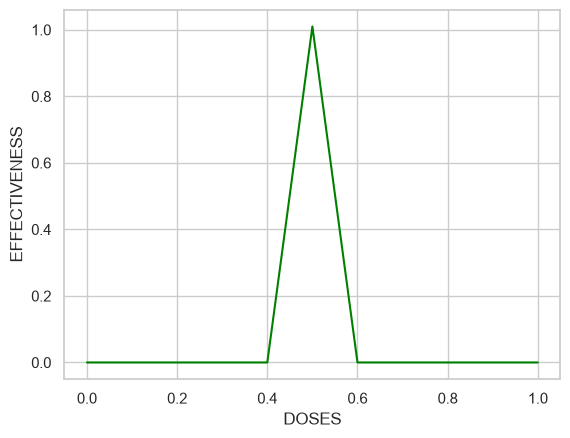

In [11]:
sns.set(style="whitegrid")

sns.lineplot(
    x= input_doses,
    y = ouput_val,
    color='green'
)

plt.xlabel("DOSES")
plt.ylabel("EFFECTIVENESS")
plt.show()

# WITH LIGHTNING

In [50]:
class LightningNN(L.LightningModule):

    def __init__(self):
        super().__init__()
        # self.input = input

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)

        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(0.), requires_grad=True)

        self.learning_rate = 0.01

    def forward(self, input) : 
        input_to_top_relu = (input*self.w00) + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = (input*self.w10) + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = (scaled_top_relu_output + 
                               scaled_bottom_relu_output + 
                               self.final_bias)
        
        output = F.relu(input_to_final_relu)
        return output 


In [51]:
input_doses = torch.linspace(start = 0, end= 1, steps = 11 )
model = LightningNN()
output_vals = model(input_doses)
output_vals
# input_doses

tensor([ 0.0000,  3.4020,  6.8040, 10.2060, 13.6080, 17.0100, 13.4760,  9.9420,
         6.4080,  2.8740,  0.0000], grad_fn=<ReluBackward0>)

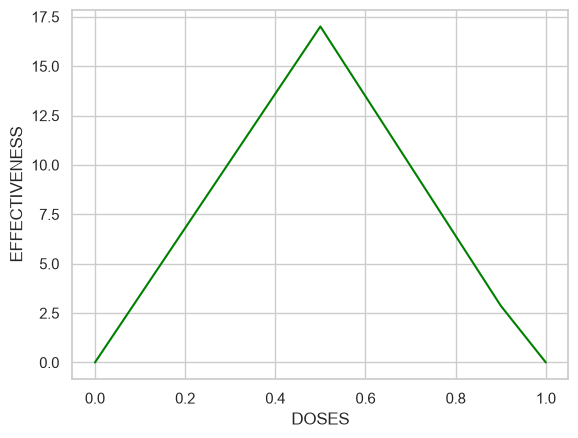

In [52]:
sns.set(style="whitegrid")

sns.lineplot(
    x= input_doses,
    y = output_vals.detach(),
    color='green'
)

plt.xlabel("DOSES")
plt.ylabel("EFFECTIVENESS")
plt.show()

# FITTING ON TRAINING DATA 

In [61]:
class LightningNN(L.LightningModule):

    def __init__(self):
        super().__init__()
        # self.input = input

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)

        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(0.), requires_grad=True)

        self.learning_rate = 0.01

    def forward(self, input) : 
        input_to_top_relu = (input*self.w00) + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = (input*self.w10) + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = (scaled_top_relu_output + 
                               scaled_bottom_relu_output + 
                               self.final_bias)
        
        output = F.relu(input_to_final_relu)
        return output 

    def configure_optimizers(self):
        return SGD(self.parameters(), lr=self.learning_rate)
    
    def training_step(self, batch, batch_idx):
        
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = (output_i - label_i)**2

        return loss 

In [66]:
inputs = torch.tensor([0., 0.5, 1.] * 100)
labels = torch.tensor([0., 1., 0.] * 100)

dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)


In [73]:
model = LightningNN()
trainer = L.Trainer(max_epochs=34, accelerator="auto", devices="auto")
tuner = L.pytorch.tuner.Tuner(trainer)

lr_find_results = tuner.lr_find(model,
                                train_dataloaders = dataloader,
                                min_lr = 0.001,
                                max_lr = 1.0,
                                early_stop_threshold = None)



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.
`Trainer.fit` stopped: `max_steps=100` reached.
Finding best initial lr: 100%|██████████| 100/100 [00:00<00:00, 1401.04it/s]
Restoring states from the checkpoint path at c:\Users\ESHAAN\Documents\Ideaverse Lite 1.5\ML - Code\Pytorch\.lr_find_0aefdb30-77f8-4329-a8cb-7b061ec5031c.ckpt
Restored all states from the checkpoint at c:\Users\ESHAAN\Documents\Ideaverse Lite 1.5\ML - Code\Pytorch\.lr_find_0aefdb30-77f8-4329-a8cb-7b061ec5031c.ckp

In [74]:
new_lr = lr_find_results.suggestion()
print(f"lr_find() suggests {new_lr:.5f} got the learning rate")

lr_find() suggests 0.00214 got the learning rate


In [75]:
model.learning_rate = new_lr
trainer.fit(model, train_dataloaders=dataloader)

print(model.final_bias.data)


  | Name         | Type | Params | Mode | FLOPs
-----------------------------------------------------
  | other params | n/a  | 7      | n/a  | n/a  
-----------------------------------------------------
1         Trainable params
6         Non-trainable params
7         Total params
0.000     Total estimated model params size (MB)
0         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 33: 100%|██████████| 300/300 [00:00<00:00, 478.81it/s, v_num=8]

`Trainer.fit` stopped: `max_epochs=34` reached.


Epoch 33: 100%|██████████| 300/300 [00:00<00:00, 475.84it/s, v_num=8]
tensor(-16.0098)


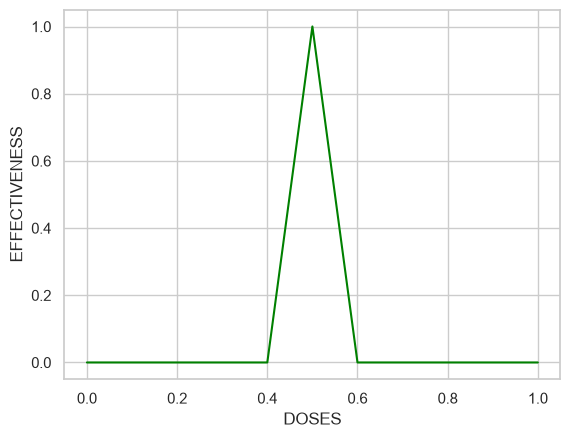

In [71]:
sns.set(style="whitegrid")
output_vals = model(input_doses) 
sns.lineplot(
    x= input_doses,
    y = output_vals.detach(),
    color='green'
)

plt.xlabel("DOSES")
plt.ylabel("EFFECTIVENESS")
plt.show()